In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
# Load the data
data = pd.read_csv('./census-bureau.data')
cols = pd.read_csv('./census-bureau.columns', header=None)

In [4]:
with open("census-bureau.columns", "r", encoding="utf-8") as f:
    cols = [line.strip() for line in f if line.strip()]

# 2) Read data using those names
df = pd.read_csv(
    "census-bureau.data",
    header=None,
    names=cols,
    sep=",",
    skipinitialspace=True
)

print(df.shape)
print(df.head())

(199523, 42)
   age                 class of worker  detailed industry recode  \
0   73                 Not in universe                         0   
1   58  Self-employed-not incorporated                         4   
2   18                 Not in universe                         0   
3    9                 Not in universe                         0   
4   10                 Not in universe                         0   

   detailed occupation recode                   education  wage per hour  \
0                           0        High school graduate              0   
1                          34  Some college but no degree              0   
2                           0                  10th grade              0   
3                           0                    Children              0   
4                           0                    Children              0   

  enroll in edu inst last wk   marital stat          major industry code  \
0            Not in universe        Widowed  

In [18]:
print(df.columns)

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [19]:
df.describe()

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


### Convert Numeric codes to categorical variables

In [5]:
# detailed industry recode and detailed occupation recode should be categorical variables, we can convert them to categorical data types
df['detailed_industry_recode'] = df['detailed industry recode'].astype('category')
df['detailed_occupation_recode'] = df['detailed occupation recode'].astype('category')

### Class imbalance 187141 vs 12382 = 15:1

In [21]:
df['label'].value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [22]:
# Lets first seperate the Categorical and Numerical columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Categorical Columns: {categorical_cols} Length: {len(categorical_cols)}")
print(f"Numerical Columns: {numerical_cols} Length: {len(numerical_cols)}")

Categorical Columns: Index(['class of worker', 'education', 'enroll in edu inst last wk',
       'marital stat', 'major industry code', 'major occupation code', 'race',
       'hispanic origin', 'sex', 'member of a labor union',
       'reason for unemployment', 'full or part time employment stat',
       'tax filer stat', 'region of previous residence',
       'state of previous residence', 'detailed household and family stat',
       'detailed household summary in household',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'family members under 18',
       'country of birth father', 'country of birth mother',
       'country of birth self', 'citizenship',
       'fill inc questionnaire for veteran's admin', 'label'],
      dtype='str') Length: 29
Numerical Columns: Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'wage 

## Categorical Variables Exploration

In [9]:
# 29 Categorical Columns are quite a lot, lets see if we can reduce them by looking at the unique values in each column
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: class of worker Unique Values: 9
Column: education Unique Values: 17
Column: enroll in edu inst last wk Unique Values: 3
Column: marital stat Unique Values: 7
Column: major industry code Unique Values: 24
Column: major occupation code Unique Values: 15
Column: race Unique Values: 5
Column: hispanic origin Unique Values: 9
Column: sex Unique Values: 2
Column: member of a labor union Unique Values: 3
Column: reason for unemployment Unique Values: 6
Column: full or part time employment stat Unique Values: 8
Column: tax filer stat Unique Values: 6
Column: region of previous residence Unique Values: 6
Column: state of previous residence Unique Values: 51
Column: detailed household and family stat Unique Values: 38
Column: detailed household summary in household Unique Values: 8
Column: migration code-change in msa Unique Values: 10
Column: migration code-change in reg Unique Values: 9
Column: migration code-move within reg Unique Values: 10
Column: live in this house 1 year ago Uniq

### Replace values which are less than 5% of the dataset with 'Other' in categorical variables

In [70]:
# To make the baseline formation more effecient lets first say that we only want to keep the categories which are atleast 5% of the total values in the dataset, and we will replace the rest with 'Other'
df_before = df.copy()
for col in [col for col in categorical_cols if col != 'label']:
    value_counts = df[col].value_counts(normalize=True)
    to_replace = value_counts[value_counts < 0.05].index
    if isinstance(df[col].dtype, pd.CategoricalDtype) and 'Other' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(['Other'])
    df[col] = df[col].replace(to_replace, 'Other')

/tmp/ipykernel_85205/1712627791.py:6: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]) and 'Other' not in df[col].cat.categories:
/tmp/ipykernel_85205/1712627791.py:6: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]) and 'Other' not in df[col].cat.categories:
/tmp/ipykernel_85205/1712627791.py:6: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]) and 'Other' not in df[col].cat.categories:
/tmp/ipykernel_85205/1712627791.py:6: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  i

In [72]:
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: detailed industry recode Unique Values: 3
Column: detailed occupation recode Unique Values: 2
Column: education Unique Values: 4
Column: marital stat Unique Values: 5
Column: race Unique Values: 3
Column: sex Unique Values: 2
Column: full or part time employment stat Unique Values: 4
Column: tax filer stat Unique Values: 4
Column: detailed household and family stat Unique Values: 6
Column: detailed household summary in household Unique Values: 5
Column: num persons worked for employer Unique Values: 7
Column: country of birth father Unique Values: 3
Column: country of birth mother Unique Values: 3
Column: country of birth self Unique Values: 2
Column: citizenship Unique Values: 3
Column: own business or self employed Unique Values: 3
Column: veterans benefits Unique Values: 3
Column: weeks worked in year Unique Values: 3
Column: year Unique Values: 2
Column: label Unique Values: 2
Column: detailed_industry_recode Unique Values: 3
Column: detailed_occupation_recode Unique Values

In [79]:
categorical_cols = df.select_dtypes(include=['object', 'str', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Categorical Columns: {categorical_cols} Length: {len(categorical_cols)}")
print(f"Numerical Columns: {numerical_cols} Length: {len(numerical_cols)}")

Categorical Columns: Index(['detailed industry recode', 'detailed occupation recode', 'education',
       'marital stat', 'race', 'sex', 'full or part time employment stat',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'label', 'detailed_industry_recode',
       'detailed_occupation_recode'],
      dtype='str') Length: 22
Numerical Columns: Index(['age', 'wage per hour', 'capital gains', 'capital losses',
       'dividends from stocks', 'weight'],
      dtype='str') Length: 6


In [81]:
df['detailed industry recode'] = df['detailed industry recode'].astype('category')
df['detailed occupation recode'] = df['detailed occupation recode'].astype('category')
df.drop(columns=['detailed industry recode', 'detailed occupation recode'], inplace=True)

In [84]:
categorical_cols = df.select_dtypes(include=['object', 'str', 'category']).columns  
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Categorical Columns: {categorical_cols} Length: {len(categorical_cols)}")
print(f"Numerical Columns: {numerical_cols} Length: {len(numerical_cols)}")


Categorical Columns: Index(['education', 'marital stat', 'race', 'sex',
       'full or part time employment stat', 'tax filer stat',
       'detailed household and family stat',
       'detailed household summary in household',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'label', 'detailed_industry_recode',
       'detailed_occupation_recode'],
      dtype='str') Length: 20
Numerical Columns: Index(['age', 'wage per hour', 'capital gains', 'capital losses',
       'dividends from stocks', 'weight'],
      dtype='str') Length: 6


In [85]:
# print all the unique values in each column as a plain list after the name of the column
for col in categorical_cols:
    unique_values = df[col].dropna().astype('object').unique().tolist()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: education Unique Values: ['High School', 'Other', 'Not High School Graduate', 'Bachelors']
Column: marital stat Unique Values: ['Widowed', 'Divorced', 'Never married', 'Married-civilian spouse present', 'Other']
Column: race Unique Values: ['White', 'Other', 'Black']
Column: sex Unique Values: ['Female', 'Male']
Column: full or part time employment stat Unique Values: ['Not in labor force', 'Children or Armed Forces', 'Full-time schedules', 'Other']
Column: tax filer stat Unique Values: ['Nonfiler', 'Other', 'Joint both under 65', 'Single']
Column: detailed household and family stat Unique Values: ['Other', 'Householder', 'Child 18+ never marr Not in a subfamily', 'Child <18 never marr not in subfamily', 'Spouse of householder', 'Nonfamily householder']
Column: detailed household summary in household Unique Values: ['Other', 'Householder', 'Child 18 or older', 'Child under 18 never married', 'Spouse of householder']
Column: num persons worked for employer Unique Values: [0, 1, 

In [86]:
# check NA
for col in df.columns:
    na_count = df[col].isna().mean() * 100
    print(f"Column: {col} NA%: {na_count:.2f}%")

Column: age NA%: 0.00%
Column: education NA%: 0.00%
Column: wage per hour NA%: 0.00%
Column: marital stat NA%: 0.00%
Column: race NA%: 0.00%
Column: sex NA%: 0.00%
Column: full or part time employment stat NA%: 0.00%
Column: capital gains NA%: 0.00%
Column: capital losses NA%: 0.00%
Column: dividends from stocks NA%: 0.00%
Column: tax filer stat NA%: 0.00%
Column: detailed household and family stat NA%: 0.00%
Column: detailed household summary in household NA%: 0.00%
Column: weight NA%: 0.00%
Column: num persons worked for employer NA%: 0.00%
Column: country of birth father NA%: 3.36%
Column: country of birth mother NA%: 3.07%
Column: country of birth self NA%: 1.70%
Column: citizenship NA%: 0.00%
Column: own business or self employed NA%: 0.00%
Column: veterans benefits NA%: 0.00%
Column: weeks worked in year NA%: 0.00%
Column: year NA%: 0.00%
Column: label NA%: 0.00%
Column: detailed_industry_recode NA%: 0.00%
Column: detailed_occupation_recode NA%: 0.00%


In [94]:
df['label'] = pd.to_numeric(df['label'].astype('object').replace({'- 50000.': 0, '50000+.': 1, '0': 0, '1': 1, 0: 0, 1: 1, 'Other': 1}), errors='raise').astype('int64')

ValueError: Cannot cast object dtype to int64

In [92]:
model_train_and_evaluate(df)

ValueError: Cannot cast object dtype to int64

### Replace Not in universe and ? and nan as missing value (pd.na) and All other is the same as Other

In [6]:
# okay so Not in Universe and ? and nan should be treated as missing values, we can replace them with np.nan and All other is basically Other
# lets first refresh the df to df_before and then replace the values
#df = df_before.copy()
df.replace(['Not in universe', '?', 'nan'], pd.NA, inplace=True)
df.replace('All other', 'Other', inplace=True)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label,detailed_industry_recode,detailed_occupation_recode
0,73,NaN,0,0,High school graduate,0,NaN,Widowed,Not in universe or children,NaN,White,Other,Female,NaN,NaN,Not in labor force,0,0,0,Nonfiler,NaN,NaN,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,0,95,- 50000.,0,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,NaN,Divorced,Construction,Precision production craft & repair,White,Other,Male,NaN,NaN,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,52,94,- 50000.,4,34
2,18,NaN,0,0,10th grade,0,High school,Never married,Not in universe or children,NaN,Asian or Pacific Islander,Other,Female,NaN,NaN,Not in labor force,0,0,0,Nonfiler,NaN,NaN,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,NaN,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,NaN,2,0,95,- 50000.,0,0
3,9,NaN,0,0,Children,0,NaN,Never married,Not in universe or children,NaN,White,Other,Female,NaN,NaN,Children or Armed Forces,0,0,0,Nonfiler,NaN,NaN,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,NaN,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,NaN,0,0,94,- 50000.,0,0
4,10,NaN,0,0,Children,0,NaN,Never married,Not in universe or children,NaN,White,Other,Female,NaN,NaN,Children or Armed Forces,0,0,0,Nonfiler,NaN,NaN,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,NaN,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,NaN,0,0,94,- 50000.,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,NaN,0,0,7th and 8th grade,0,NaN,Married-civilian spouse present,Not in universe or children,NaN,White,Other,Male,NaN,NaN,Not in labor force,0,0,0,Joint both 65+,NaN,NaN,Householder,Householder,955.27,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,NaN,Canada,United-States,United-States,Native- Born in the United States,0,NaN,2,0,95,- 50000.,0,0
199519,65,Self-employed-incorporated,37,2,11th grade,0,NaN,Married-civilian spouse present,Business and repair services,Executive admin and managerial,White,Other,Male,NaN,NaN,Children or Armed Forces,6418,0,9,Joint one under 65 & one 65+,NaN,NaN,Householder,Householder,687.19,Nonmover,Nonmover,Nonmover,Yes,NaN,1,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,52,94,- 50000.,37,2
199520,47,NaN,0,0,Some college but no degree,0,NaN,Married-civilian spouse present,Not in universe or children,NaN,White,Other,Male,NaN,NaN,Children 

In [24]:
# Lets check the na values in each column
df.isna().sum()

age                                                0
class of worker                               100245
detailed industry recode                           0
detailed occupation recode                         0
education                                          0
wage per hour                                      0
enroll in edu inst last wk                    186943
marital stat                                       0
major industry code                                0
major occupation code                         100684
race                                               0
hispanic origin                                  874
sex                                                0
member of a labor union                       180459
reason for unemployment                       193453
full or part time employment stat                  0
capital gains                                      0
capital losses                                     0
dividends from stocks                         

### Lot more NA values after the replace and we drop columns which have more than 20% NA values 

In [7]:
# lets remove the columns which have more than 20% missing values
threshold = len(df) * 0.2
cols_to_drop = df.columns[df.isna().sum() > threshold]
print(f"Columns to drop: {cols_to_drop}")
df_before_drop = df.copy()
df.drop(columns=cols_to_drop, inplace=True)

Columns to drop: Index(['class of worker', 'enroll in edu inst last wk',
       'major occupation code', 'member of a labor union',
       'reason for unemployment', 'region of previous residence',
       'state of previous residence', 'migration code-change in msa',
       'migration code-change in reg', 'migration code-move within reg',
       'migration prev res in sunbelt', 'family members under 18',
       'fill inc questionnaire for veteran's admin'],
      dtype='str')


### We have dropped a significant number of columns approximately 13 columns
### Lets make an xgboost baseline model first on the df_before_drop and then on the df_after_drop to see the difference in performance

In [9]:
def encode_income_label(series):
    label_map = {'- 50000.': 0, '50000+.': 1, '0': 0, '1': 1, 0: 0, 1: 1, 'Other': 1}
    encoded = pd.to_numeric(series.astype('object').replace(label_map), errors='coerce')
    invalid = series[encoded.isna()].dropna().astype('object').unique().tolist()
    if invalid:
        raise ValueError(f"Unexpected label values: {invalid}. Expected '- 50000.', '50000+.', 0, or 1.")
    return encoded.astype('int64')

df_before_drop['label'] = encode_income_label(df_before_drop['label'])
df['label'] = encode_income_label(df['label'])

,age,detailed industry recode,detailed occupation recode,education,wage per hour,marital stat,major industry code,race,hispanic origin,sex,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,detailed household and family stat,detailed household summary in household,weight,live in this house 1 year ago,num persons worked for employer,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,year,label,detailed_industry_recode,detailed_occupation_recode
0,73,0,0,High school graduate,0,Widowed,Not in universe or children,White,Other,Female,Not in labor force,0,0,0,Nonfiler,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,Not in universe under 1 year old,0,United-States,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0
1,58,4,34,Some college but no degree,0,Divorced,Construction,White,Other,Male,Children or Armed Forces,0,0,0,Head of household,Householder,Householder,1053.55,No,1,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,0,4,34
2,18,0,0,10th grade,0,Never married,Not in universe or children,Asian or Pacific Islander,Other,Female,Not in labor force,0,0,0,Nonfiler,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,Not in universe under 1 year old,0,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,2,0,95,0,0,0
3,9,0,0,Children,0,Never married,Not in universe or children,White,Other,Female,Children or Armed Forces,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Yes,0,United-States,United-States,United-States,Native- Born in the United States,0,0,0,94,0,0,0
4,10,0,0,Children,0,Never married,Not in universe or children,White,Other,Female,Children or Armed Forces,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Yes,0,United-States,United-States,United-States,Native- Born in the United States,0,0,0,94,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,0,0,7th and 8th grade,0,Married-civilian spouse present,Not in universe or children,White,Other,Male,Not in labor force,0,0,0,Joint both 65+,Householder,Householder,955.27,Not in universe under 1 year old,0,Canada,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0
199519,65,37,2,11th grade,0,Married-civilian spouse present,Business and repair services,White,Other,Male,Children or Armed Forces,6418,0,9,Joint one under 65 & one 65+,Householder,Householder,687.19,Yes,1,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,0,37,2
199520,47,0,0,Some college but no degree,0,Married-civilian spouse present,Not in universe or children,White,Other,Male,Children or Armed Forces,0,0,157,Joint both under 65,Householder,Householder,1923.03,Not in universe under 1 year old,6,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,2,52,95,0,0,0
199521,16,0,0,10th grade,0,Never married,Not in universe or children,White,Other,Female,Not in labor force,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,4664.87,Not in universe under 1 year old,0,United-States,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0


In [96]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df_before_drop.drop('label', axis=1).copy()
y = encode_income_label(df_before_drop['label'])

# XGBoost requires categorical columns to have dtype='category' when enable_categorical=True.
object_cols = X.select_dtypes(include=['object', 'str']).columns
for col in object_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    eval_metric='logloss',
    enable_categorical=True,
    #tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Macro F1 Score: {classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.73      0.49      0.59      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.74      0.78     39905
weighted avg       0.95      0.96      0.95     39905

[[36982   447]
 [ 1267  1209]]
Macro F1 Score: 0.7813


### We don't see much of a difference in the performance of the model before and after dropping the columns. We get a macro F1 score of 0.78 in both cases. This indicates that the dropped columns were not contributing much to the model's performance, and their removal did not negatively impact the model's ability to classify the data.

In [27]:
def model_train_and_evaluate(df):
    X = df.drop('label', axis=1).copy()
    y = encode_income_label(df['label'])

    # XGBoost requires categorical columns to have dtype='category' when enable_categorical=True.
    object_cols = X.select_dtypes(include=['object', 'str']).columns
    for col in object_cols:
        X[col] = X[col].astype('category')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = xgb.XGBClassifier(
        eval_metric='logloss',
        enable_categorical=True,
        #tree_method='hist',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(f"Macro F1 Score: {classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']:.4f}")

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop('label', axis=1).copy()
y = encode_income_label(df['label'])

# XGBoost requires categorical columns to have dtype='category' when enable_categorical=True.
object_cols = X.select_dtypes(include=['object', 'str']).columns
for col in object_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    eval_metric='logloss',
    enable_categorical=True,
    #tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Macro F1 Score: {classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']:.4f}")

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.73      0.49      0.58      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.74      0.78     39905
weighted avg       0.95      0.96      0.95     39905

[[36985   444]
 [ 1271  1205]]
Macro F1 Score: 0.7808


In [27]:
df.shape, df_before_drop.shape

((199523, 31), (199523, 44))

In [14]:
# print each columns missing values in percentage
for col in df.columns:
    missing_percentage = df[col].isna().mean() * 100
    print(f"Column: {col} Missing Percentage: {missing_percentage:.2f}%")

Column: age Missing Percentage: 0.00%
Column: detailed industry recode Missing Percentage: 0.00%
Column: detailed occupation recode Missing Percentage: 0.00%
Column: education Missing Percentage: 0.00%
Column: wage per hour Missing Percentage: 0.00%
Column: marital stat Missing Percentage: 0.00%
Column: major industry code Missing Percentage: 0.00%
Column: race Missing Percentage: 0.00%
Column: hispanic origin Missing Percentage: 0.44%
Column: sex Missing Percentage: 0.00%
Column: full or part time employment stat Missing Percentage: 0.00%
Column: capital gains Missing Percentage: 0.00%
Column: capital losses Missing Percentage: 0.00%
Column: dividends from stocks Missing Percentage: 0.00%
Column: tax filer stat Missing Percentage: 0.00%
Column: detailed household and family stat Missing Percentage: 0.00%
Column: detailed household summary in household Missing Percentage: 0.00%
Column: weight Missing Percentage: 0.00%
Column: live in this house 1 year ago Missing Percentage: 0.00%
Colu

In [18]:
# rebuild categorical_cols and numerical_cols after dropping the columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Categorical Columns: {categorical_cols} Length: {len(categorical_cols)}")
print(f"Numerical Columns: {numerical_cols} Length: {len(numerical_cols)}")

Categorical Columns: Index(['education', 'marital stat', 'major industry code', 'race',
       'hispanic origin', 'sex', 'full or part time employment stat',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'live in this house 1 year ago', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'label'],
      dtype='str') Length: 16
Numerical Columns: Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'wage per hour', 'capital gains', 'capital losses',
       'dividends from stocks', 'weight', 'num persons worked for employer',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year'],
      dtype='str') Length: 13


In [19]:
for col in categorical_cols:
    unique_values = df[col].dropna().astype('object').unique().tolist()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: education Unique Values: 17
Column: marital stat Unique Values: 7
Column: major industry code Unique Values: 24
Column: race Unique Values: 5
Column: hispanic origin Unique Values: 9
Column: sex Unique Values: 2
Column: full or part time employment stat Unique Values: 8
Column: tax filer stat Unique Values: 6
Column: detailed household and family stat Unique Values: 38
Column: detailed household summary in household Unique Values: 8
Column: live in this house 1 year ago Unique Values: 3
Column: country of birth father Unique Values: 42
Column: country of birth mother Unique Values: 42
Column: country of birth self Unique Values: 42
Column: citizenship Unique Values: 5
Column: label Unique Values: 2


In [20]:
df.shape

(199523, 31)

In [21]:
# 17 values in education is a lot maybe we can reduce it by looking at the unique values in the education column and then grouping them into categories like High School, Bachelors, Masters, PhD, etc.

df['education'].unique()

<ArrowStringArray>
[                  'High school graduate',
             'Some college but no degree',
                             '10th grade',
                               'Children',
             'Bachelors degree(BA AB BS)',
 'Masters degree(MA MS MEng MEd MSW MBA)',
                    'Less than 1st grade',
     'Associates degree-academic program',
                      '7th and 8th grade',
                  '12th grade no diploma',
    'Associates degree-occup /vocational',
 'Prof school degree (MD DDS DVM LLB JD)',
                       '5th or 6th grade',
                             '11th grade',
              'Doctorate degree(PhD EdD)',
                              '9th grade',
               '1st 2nd 3rd or 4th grade']
Length: 17, dtype: str

In [22]:
df['education'].value_counts(normalize=True)

education
High school graduate                      0.242614
Children                                  0.237677
Some college but no degree                0.139433
Bachelors degree(BA AB BS)                0.099562
7th and 8th grade                         0.040131
10th grade                                0.037875
11th grade                                0.034462
Masters degree(MA MS MEng MEd MSW MBA)    0.032783
9th grade                                 0.031224
Associates degree-occup /vocational       0.026854
Associates degree-academic program        0.021867
5th or 6th grade                          0.016424
12th grade no diploma                     0.010655
1st 2nd 3rd or 4th grade                  0.009017
Prof school degree (MD DDS DVM LLB JD)    0.008986
Doctorate degree(PhD EdD)                 0.006330
Less than 1st grade                       0.004105
Name: proportion, dtype: float64

In [26]:
# Compare each education group's <=50K rate to the overall <=50K rate.
# A value > 1 means that education group is overrepresented in <=50K.
low_income_label = 0

education_summary = df.groupby('education').agg(
    education_total=('label', 'size'),
    low_income_count=('label', lambda x: (x == low_income_label).sum())
)

overall_low_income_rate = (df['label'] == low_income_label).mean()

print(overall_low_income_rate)

education_summary['low_income_rate'] = (
    education_summary['low_income_count'] / education_summary['education_total']
)
education_summary['low_income_lift'] = (
    education_summary['low_income_rate'] / overall_low_income_rate
)

education_summary.sort_values('low_income_lift', ascending=False)

0.9379419916500854


,education_total,low_income_count,low_income_rate,low_income_lift
education,,,,
Not High School Graduate,84113,83801,0.996291,1.062209
High School,48407,46528,0.961183,1.024779
Other,39334,35753,0.908959,0.969100
Bachelors,19865,15950,0.802920,0.856044
Masters,6541,4503,0.688427,0.733976
PhD,1263,606,0.479810,0.511556


In [71]:
# Group the low-income-heavy schooling levels together so education has a smaller, cleaner set of categories.
education_map = {
    'Children': 'Not High School Graduate',
    'Preschool': 'Not High School Graduate',
    'Less than 1st grade': 'Not High School Graduate',
    '1st 2nd 3rd or 4th grade': 'Not High School Graduate',
    '5th or 6th grade': 'Not High School Graduate',
    '7th and 8th grade': 'Not High School Graduate',
    '9th grade': 'Not High School Graduate',
    '10th grade': 'Not High School Graduate',
    '11th grade': 'Not High School Graduate',
    '12th grade no diploma': 'Not High School Graduate',
    'High school graduate': 'High School',
    'Bachelors degree(BA AB BS)': 'Bachelors',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Masters',
    'Doctorate degree(PhD EdD)': 'PhD',
    'Some college but no degree': 'Other',
    'Associate degree-occup /vocational': 'Other',
    'Associates degree-occup /vocational': 'Other',
    'Associate degree-academic program': 'Other',
    'Associates degree-academic program': 'Other',
    'Prof school degree (MD DDS DVM LLB JD)': 'Other',
}

df['education'] = df['education'].astype('object').replace(education_map).astype('category')

## We have more meaningful features now and we didn't lose performance by making those buckets

In [28]:
# Quickly check the performance of the model after this change to see if it has improved or not, we will use the same code as before to train the model and evaluate it.
model_train_and_evaluate(df)


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.73      0.48      0.58      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.74      0.78     39905
weighted avg       0.95      0.96      0.95     39905

[[36986   443]
 [ 1277  1199]]
Macro F1 Score: 0.7798


In [29]:
# Number of unique values in each categorical column after the change
for col in categorical_cols:
    unique_values = df[col].dropna().astype('object').unique().tolist()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: education Unique Values: 6
Column: marital stat Unique Values: 7
Column: major industry code Unique Values: 24
Column: race Unique Values: 5
Column: hispanic origin Unique Values: 9
Column: sex Unique Values: 2
Column: full or part time employment stat Unique Values: 8
Column: tax filer stat Unique Values: 6
Column: detailed household and family stat Unique Values: 38
Column: detailed household summary in household Unique Values: 8
Column: live in this house 1 year ago Unique Values: 3
Column: country of birth father Unique Values: 42
Column: country of birth mother Unique Values: 42
Column: country of birth self Unique Values: 42
Column: citizenship Unique Values: 5
Column: label Unique Values: 2


In [31]:
# Lets group those with less than 5% values in the dataset into 'Other' category
for col in [col for col in categorical_cols if col != 'label']:
    value_counts = df[col].value_counts(normalize=True)
    to_replace = value_counts[value_counts < 0.05].index
    if isinstance(df[col].dtype, pd.CategoricalDtype) and 'Other' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(['Other'])
    df[col] = df[col].replace(to_replace, 'Other')

In [32]:
# Test the model again after this change to see if it has improved or not, we will use the same code as before to train the model and evaluate it.
model_train_and_evaluate(df)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.73      0.47      0.57      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.73      0.77     39905
weighted avg       0.95      0.96      0.95     39905

[[36993   436]
 [ 1308  1168]]
Macro F1 Score: 0.7748


In [34]:
# check number of unique values in each categorical column after the change
for col in categorical_cols:
    unique_values = df[col].dropna().astype('object').unique().tolist()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: education Unique Values: 4
Column: marital stat Unique Values: 5
Column: major industry code Unique Values: 3
Column: race Unique Values: 3
Column: hispanic origin Unique Values: 1
Column: sex Unique Values: 2
Column: full or part time employment stat Unique Values: 4
Column: tax filer stat Unique Values: 4
Column: detailed household and family stat Unique Values: 6
Column: detailed household summary in household Unique Values: 5
Column: live in this house 1 year ago Unique Values: 3
Column: country of birth father Unique Values: 3
Column: country of birth mother Unique Values: 3
Column: country of birth self Unique Values: 2
Column: citizenship Unique Values: 3
Column: label Unique Values: 2


## We have reduced the number of unique values in the categorical columns which will help the model to learn better and also reduce the chances of overfitting. # Lets make our values make sense 

In [35]:
for col in categorical_cols:
    unique_values = df[col].dropna().astype('object').unique().tolist()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: education Unique Values: ['High School', 'Other', 'Not High School Graduate', 'Bachelors']
Categories (6, str): ['Bachelors', 'High School', 'Masters', 'Not High School Graduate', 'Other', 'PhD']
Column: marital stat Unique Values: <ArrowStringArray>
[                        'Widowed',                        'Divorced',
                   'Never married', 'Married-civilian spouse present',
                           'Other']
Length: 5, dtype: str
Column: major industry code Unique Values: <ArrowStringArray>
['Not in universe or children', 'Other', 'Retail trade']
Length: 3, dtype: str
Column: race Unique Values: <ArrowStringArray>
['White', 'Other', 'Black']
Length: 3, dtype: str
Column: hispanic origin Unique Values: <ArrowStringArray>
['Other', nan]
Length: 2, dtype: str
Column: sex Unique Values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Column: full or part time employment stat Unique Values: <ArrowStringArray>
[      'Not in labor force', 'Children or Arm

In [36]:
# There is a Not in universe or children category which should be a missing value 
# Hispanic origin doesnt add much value since it is Other or nan
# Not in universe under 1 year old should also be a missing value,

df.replace(['Not in universe or children', 'Not in universe under 1 year old'], pd.NA, inplace=True)

,age,detailed industry recode,detailed occupation recode,education,wage per hour,marital stat,major industry code,race,hispanic origin,sex,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,detailed household and family stat,detailed household summary in household,weight,live in this house 1 year ago,num persons worked for employer,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,year,label,detailed_industry_recode,detailed_occupation_recode
0,73,0,0,High School,0,Widowed,NaN,White,Other,Female,Not in labor force,0,0,0,Nonfiler,Other,Other,1700.09,NaN,0,United-States,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0
1,58,4,34,Other,0,Divorced,Other,White,Other,Male,Children or Armed Forces,0,0,0,Other,Householder,Householder,1053.55,No,1,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,0,4,34
2,18,0,0,Not High School Graduate,0,Never married,NaN,Other,Other,Female,Not in labor force,0,0,0,Nonfiler,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,0,Other,Other,Other,Foreign born- Not a citizen of U S,0,2,0,95,0,0,0
3,9,0,0,Not High School Graduate,0,Never married,NaN,White,Other,Female,Children or Armed Forces,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Yes,0,United-States,United-States,United-States,Native- Born in the United States,0,0,0,94,0,0,0
4,10,0,0,Not High School Graduate,0,Never married,NaN,White,Other,Female,Children or Armed Forces,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Yes,0,United-States,United-States,United-States,Native- Born in the United States,0,0,0,94,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,0,0,Not High School Graduate,0,Married-civilian spouse present,NaN,White,Other,Male,Not in labor force,0,0,0,Other,Householder,Householder,955.27,NaN,0,Other,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0
199519,65,37,2,Not High School Graduate,0,Married-civilian spouse present,Other,White,Other,Male,Children or Armed Forces,6418,0,9,Other,Householder,Householder,687.19,Yes,1,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,0,37,2
199520,47,0,0,Other,0,Married-civilian spouse present,NaN,White,Other,Male,Children or Armed Forces,0,0,157,Joint both under 65,Householder,Householder,1923.03,NaN,6,Other,Other,Other,Other,0,2,52,95,0,0,0
199521,16,0,0,Not High School Graduate,0,Never married,NaN,White,Other,Female,Not in labor force,0,0,0,Nonfiler,Child <18 never marr not in subfamily,Child under 18 never married,4664.87,NaN,0,United-States,United-States,United-States,Native- Born in the United States,0,2,0,95,0,0,0


In [44]:
df.isna().sum()

age                                             0
detailed industry recode                        0
detailed occupation recode                      0
education                                       0
wage per hour                                   0
marital stat                                    0
major industry code                        100684
race                                            0
hispanic origin                               874
sex                                             0
full or part time employment stat               0
capital gains                                   0
capital losses                                  0
dividends from stocks                           0
tax filer stat                                  0
detailed household and family stat              0
detailed household summary in household         0
weight                                          0
live in this house 1 year ago              101212
num persons worked for employer                 0


In [45]:
# drop cols with more than 20% missing values again
for col in categorical_cols:
    if df[col].isna().sum() > 0.2 * len(df):
        df.drop(columns=[col], inplace=True)

In [49]:
df.drop(columns=['hispanic origin'], inplace=True)

In [50]:
df.shape

(199523, 28)

In [51]:
model_train_and_evaluate(df)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     37429
           1       0.73      0.47      0.57      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.73      0.77     39905
weighted avg       0.95      0.96      0.95     39905

[[36989   440]
 [ 1306  1170]]
Macro F1 Score: 0.7748


In [63]:
# detailed industry recode and detailed occupation recode, year, vetrans benefits, num persons worked for employer,  

Index(['education', 'marital stat', 'major industry code', 'race',
       'hispanic origin', 'sex', 'full or part time employment stat',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'live in this house 1 year ago', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'label'],
      dtype='str')

In [59]:
# Lets do a number of unique values in all columns

for col in df.columns:
    unique_values = df[col].nunique()
    print(f"Column: {col} Unique Values: {unique_values}")

Column: age Unique Values: 91
Column: detailed industry recode Unique Values: 52
Column: detailed occupation recode Unique Values: 47
Column: education Unique Values: 4
Column: wage per hour Unique Values: 1240
Column: marital stat Unique Values: 5
Column: race Unique Values: 3
Column: sex Unique Values: 2
Column: full or part time employment stat Unique Values: 4
Column: capital gains Unique Values: 132
Column: capital losses Unique Values: 113
Column: dividends from stocks Unique Values: 1478
Column: tax filer stat Unique Values: 4
Column: detailed household and family stat Unique Values: 6
Column: detailed household summary in household Unique Values: 5
Column: weight Unique Values: 99800
Column: num persons worked for employer Unique Values: 7
Column: country of birth father Unique Values: 3
Column: country of birth mother Unique Values: 3
Column: country of birth self Unique Values: 2
Column: citizenship Unique Values: 3
Column: own business or self employed Unique Values: 3
Colum

In [64]:
# Honestly all the columns with less than 60 unique values, can be treated as categorical variables, 

for col in df.columns:
    if df[col].nunique() < 60:
        df[col] = df[col].astype('category')

In [67]:
# rebuild categorical_cols and numerical_cols after the change
categorical_cols = df.select_dtypes(include=['object', 'str', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Categorical Columns: {categorical_cols} Length: {len(categorical_cols)}")
print(f"Numerical Columns: {numerical_cols} Length: {len(numerical_cols)}")

Categorical Columns: Index(['detailed industry recode', 'detailed occupation recode', 'education',
       'marital stat', 'race', 'sex', 'full or part time employment stat',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'label', 'detailed_industry_recode',
       'detailed_occupation_recode'],
      dtype='str') Length: 22
Numerical Columns: Index(['age', 'wage per hour', 'capital gains', 'capital losses',
       'dividends from stocks', 'weight'],
      dtype='str') Length: 6


In [68]:
# Okay now lets convert the 5 % values in the dataset into other category and then test the model again to see if it has improved or not, we will use the same code as before to train the model and evaluate it.
for col in categorical_cols:
    value_counts = df[col].value_counts(normalize=True)
    to_replace = value_counts[value_counts < 0.05].index
    if pd.api.types.is_categorical_dtype(df[col]) and 'Other' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(['Other'])
    df[col] = df[col].replace(to_replace, 'Other')

TypeError: Cannot setitem on a Categorical with a new category (Other), set the categories first

## Even Numerical Columns have have very few unique values, with capital gains mostly represented by 0

In [62]:
# is year a numberic or categorical variable, 
print(df['year'].dtype)

int64


In [61]:
# Even numerical columns have very less unique values

In [57]:
categorical_cols

Index(['education', 'marital stat', 'major industry code', 'race',
       'hispanic origin', 'sex', 'full or part time employment stat',
       'tax filer stat', 'detailed household and family stat',
       'detailed household summary in household',
       'live in this house 1 year ago', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'label'],
      dtype='str')

In [56]:
df['own business or self employed'].value_counts()

own business or self employed
0    180672
2     16153
1      2698
Name: count, dtype: int64

## Even just using numeric columns and label and education we get a macro F1 score of 0.77 which is not bad at all. This indicates that the numeric columns are also contributing significantly to the model's performance and we can achieve good results even without using the categorical columns.

In [53]:
model_train_and_evaluate(df[numerical_cols.tolist() + ['label', 'education']])

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     37429
           1       0.75      0.43      0.55      2476

    accuracy                           0.96     39905
   macro avg       0.85      0.71      0.76     39905
weighted avg       0.95      0.96      0.95     39905

[[37065   364]
 [ 1411  1065]]
Macro F1 Score: 0.7610


In [37]:
# let see the distribution of the values in the columns after this change
for col in categorical_cols:
    norm_value_counts = df[col].value_counts(normalize=True)
    print(f"Column: {col} Normalized Value Counts: {norm_value_counts}")


Column: education Normalized Value Counts: education
Not High School Graduate    0.421570
High School                 0.242614
Other                       0.236253
Bachelors                   0.099562
Masters                     0.000000
PhD                         0.000000
Name: proportion, dtype: float64
Column: marital stat Normalized Value Counts: marital stat
Never married                      0.433459
Married-civilian spouse present    0.422117
Divorced                           0.063702
Widowed                            0.052440
Other                              0.028282
Name: proportion, dtype: float64
Column: major industry code Normalized Value Counts: major industry code
Other           0.827295
Retail trade    0.172705
Name: proportion, dtype: float64
Column: race Normalized Value Counts: race
White    0.838826
Black    0.102319
Other    0.058855
Name: proportion, dtype: float64
Column: hispanic origin Normalized Value Counts: hispanic origin
Other    1.0
Name: proportion

In [17]:
# we should look at the distribtion of the target variable with each of the categorical variables to see if there is any correlation between them. We can use the value_counts() function to see the distribution of the target variable with each of the categorical variables. This will help us to identify which categorical variables are more important for our model. We can also use the groupby() function to see the distribution of the target variable with each of the categorical variables. This will help us to identify which categorical variables are more important for our model.
for col in categorical_cols:
    print(f"Column: {col}")
    print(df.groupby(col)['label'].value_counts())
    print("\n")

Column: class of worker
class of worker                 label   
Federal government              - 50000.     2328
                                50000+.       597
Local government                - 50000.     6937
                                50000+.       847
Never worked                    - 50000.      437
                                50000+.         2
Not in universe                 - 50000.    99341
                                50000+.       904
Private                         - 50000.    64706
                                50000+.      7322
Self-employed-incorporated      - 50000.     2131
                                50000+.      1134
Self-employed-not incorporated  - 50000.     7355
                                50000+.      1090
State government                - 50000.     3742
                                50000+.       485
Without pay                     - 50000.      164
                                50000+.         1
Name: count, dtype: int64


Column:

In [23]:
print(df.groupby('education')['label'].value_counts())


education                 label   
Bachelors                 - 50000.    15950
                          50000+.      3915
High School               - 50000.    46528
                          50000+.      1879
Masters                   - 50000.     4503
                          50000+.      2038
Not High School Graduate  - 50000.    83801
                          50000+.       312
Other                     - 50000.    35753
                          50000+.      3581
PhD                       50000+.       657
                          - 50000.      606
Name: count, dtype: int64


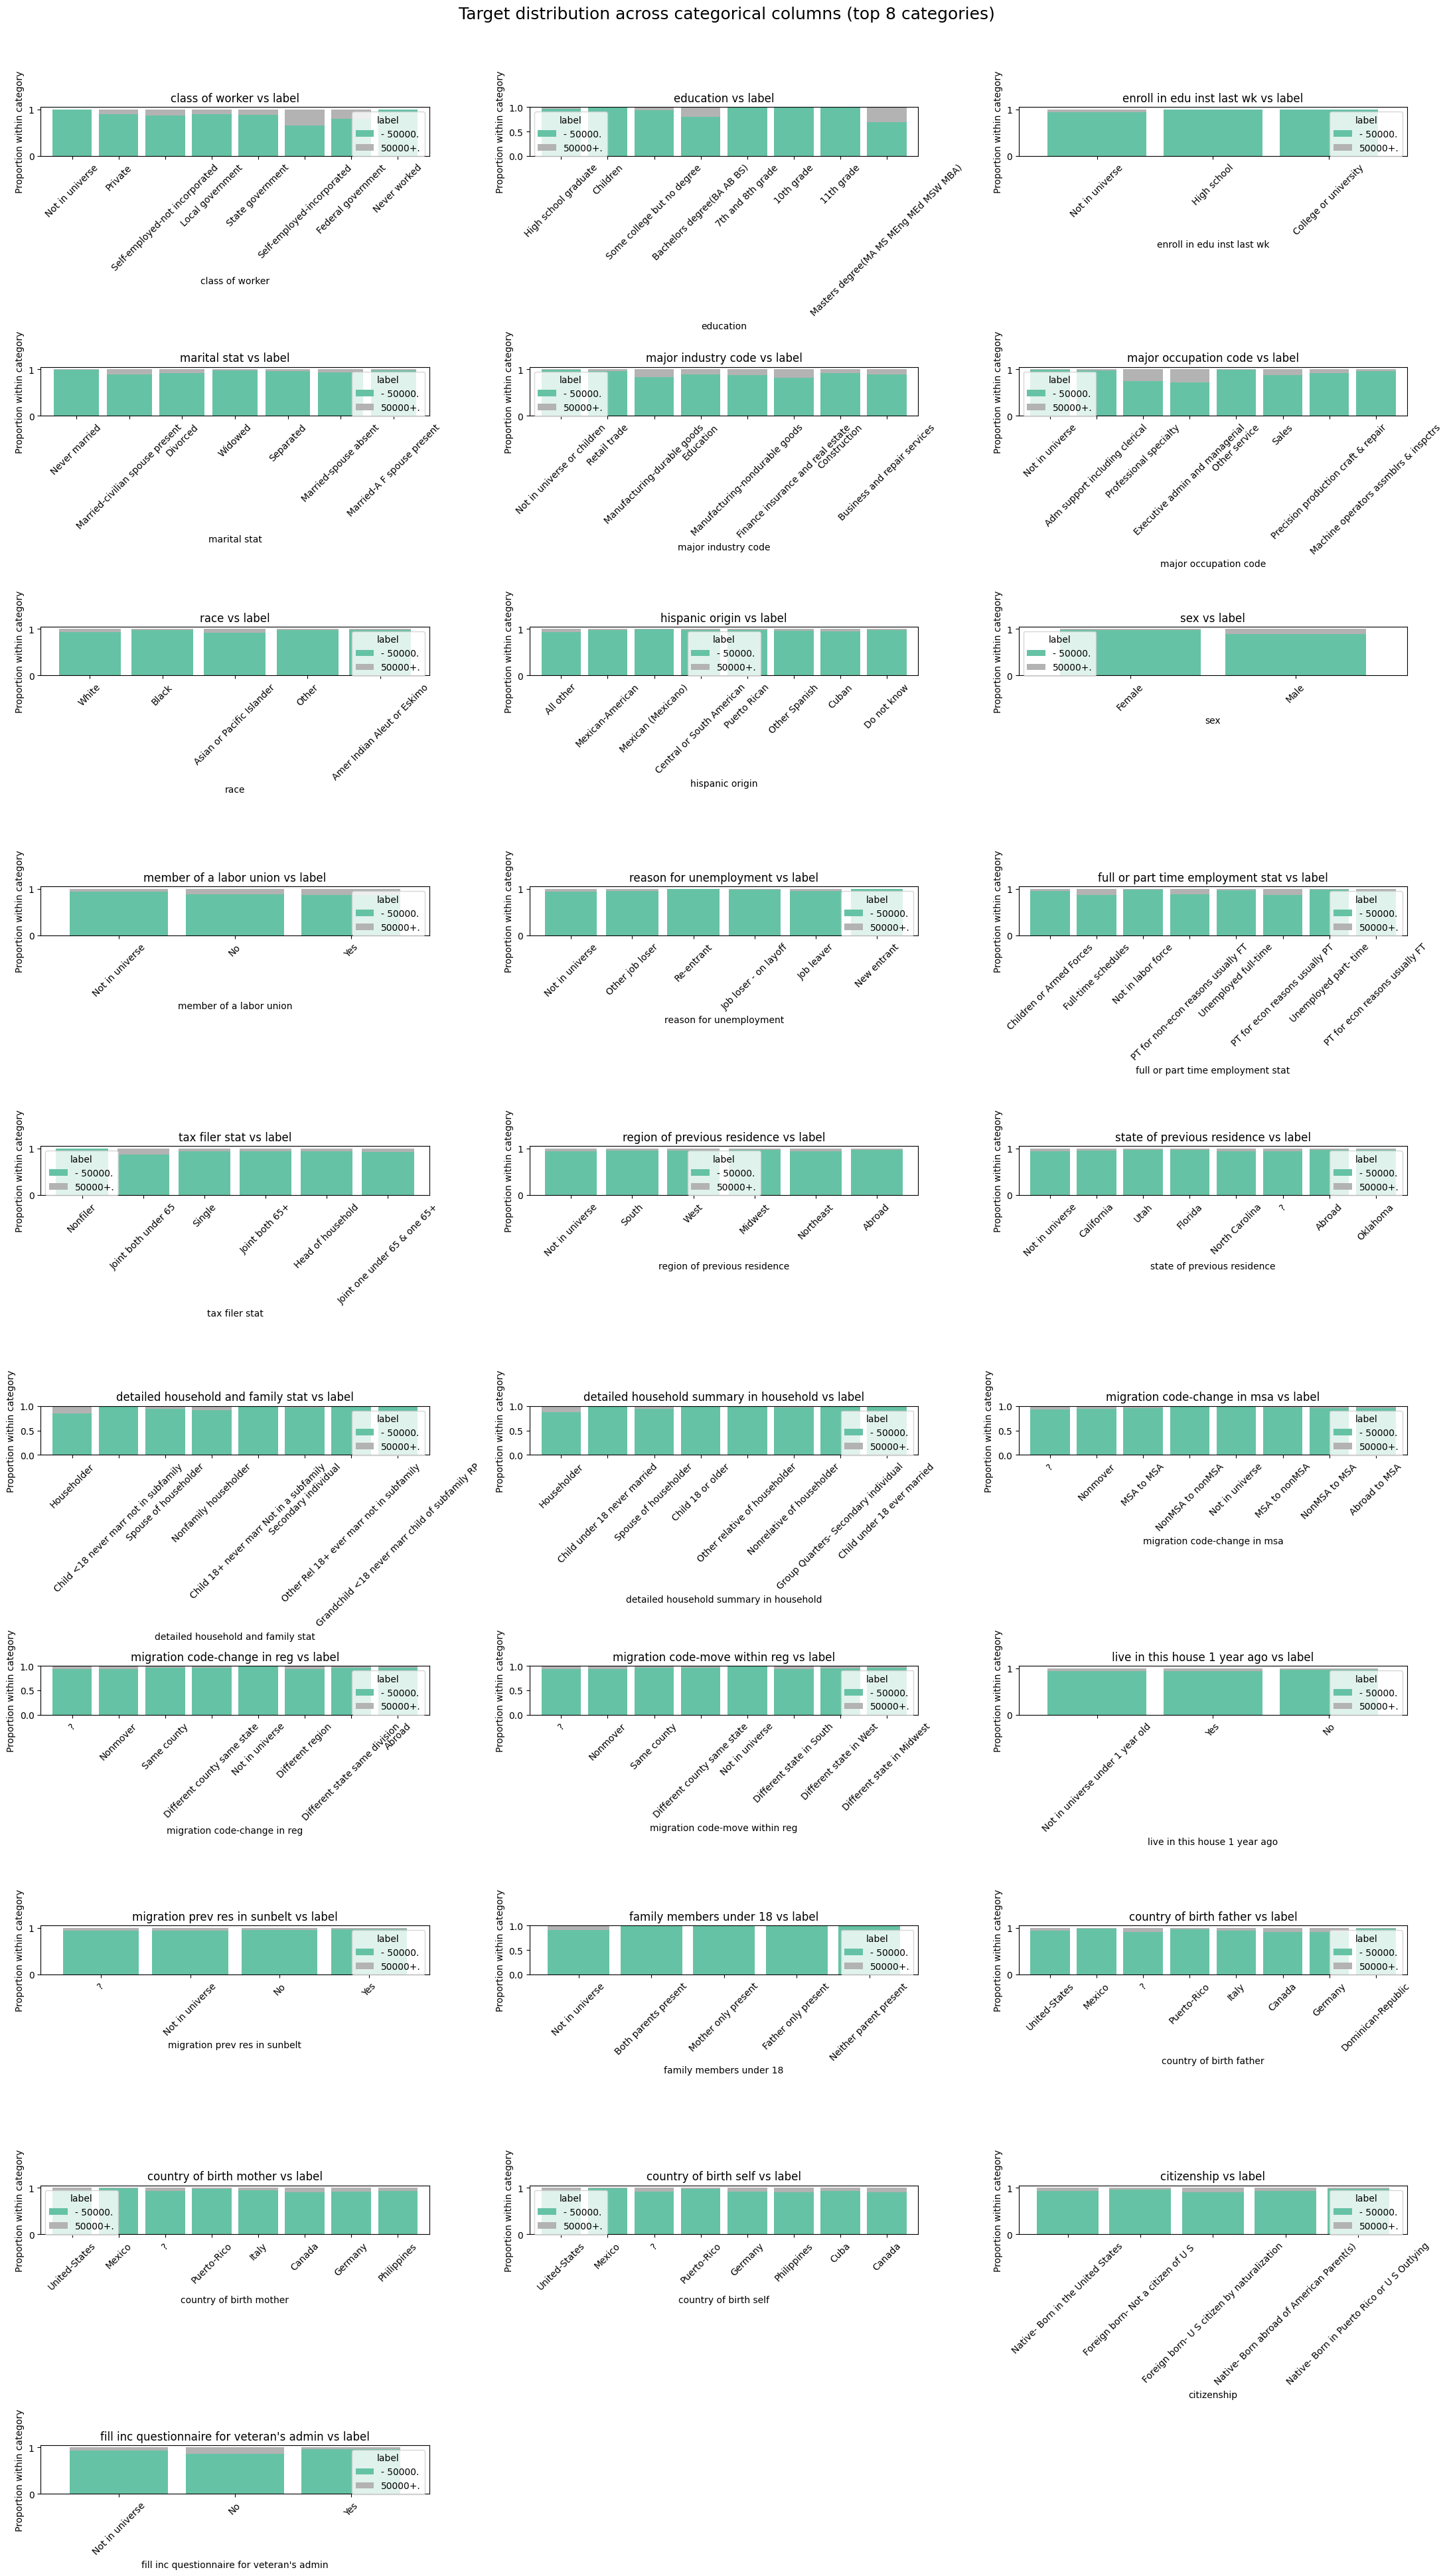

In [20]:
import math
import matplotlib.pyplot as plt

def plot_categorical_label_distribution(df, categorical_columns, target='label', top_n=8, n_cols=3, normalize=True):
    plot_columns = [col for col in categorical_columns if col != target]
    n_rows = math.ceil(len(plot_columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 3.8 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, col in zip(axes, plot_columns):
        top_categories = df[col].value_counts().nlargest(top_n).index
        plot_df = df[df[col].isin(top_categories)]

        counts = pd.crosstab(plot_df[col], plot_df[target])
        counts = counts.reindex(top_categories, fill_value=0)

        if normalize:
            counts = counts.div(counts.sum(axis=1), axis=0)

        counts.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            colormap='Set2',
            width=0.85,
        )

        ax.set_title(f'{col} vs {target}')
        ax.set_xlabel(col)
        ax.set_ylabel('Proportion within category' if normalize else 'Count')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title=target)

    for ax in axes[len(plot_columns):]:
        ax.remove()

    fig.suptitle(f'Target distribution across categorical columns (top {top_n} categories)', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_categorical_label_distribution(df, categorical_cols)


In [22]:
# Hmm the above kind of points at class imbalance, we should look at the distribution of the target variable to confirm this
print(df['label'].value_counts(normalize=True))

label
- 50000.    0.937942
50000+.     0.062058
Name: proportion, dtype: float64


In [ ]:
# This was quite obvious given the sea of green in the above plots, and is abundantly clear given the above distribution of the target variable. We have a class imbalance problem in our dataset, with the majority class being 0 (less than or equal to 50K) and the minority class being 1 (greater than 50K). This is something we will have to keep in mind when we are building our model, as it can lead to poor performance if not handled properly. We will have to use techniques such as oversampling, undersampling, or using class weights to address this issue.

# Before sampling we can try to create a baseline model using all the features and see how it performs. This will give us a good idea of how well our model is performing and will also help us to identify which features are more important for our model. We can use a simple logistic regression model as our baseline model and see how it performs on the imbalanced dataset. We can then use techniques such as oversampling, undersampling, or using class weights to address the class imbalance issue and see how it affects the performance of our model.

